# Eco-Verify: A Comparative Gap Analysis Tool for Corporate and Consumer Social Responsibility Using Machine Learning-Based Topic Modeling and NLP

**Department of Computer Science**

---

### Objective
This notebook builds a working prototype of the Eco-Verify system described in the project proposal.
It uses **Natural Language Processing (NLP)** and **Machine Learning-based Topic Modeling (LDA / NMF)**
to:
1. Analyze consumer reviews for social-responsibility themes (Consumer Social Responsibility — CnSR)
2. Analyze corporate CSR statements
3. Compare the two and highlight **gaps** between what consumers care about and what companies communicate

> **Note on data:** No public dataset of labeled CnSR reviews was available, so this notebook generates a
> realistic **synthetic dataset** (templated consumer reviews across 9 CSR themes, and templated corporate
> CSR statements from 8 fictional companies). The pipeline itself — preprocessing, TF-IDF, LDA/NMF, and gap
> analysis — is fully real and works unchanged on any real review dataset (e.g., Amazon/Flipkart reviews)
> if you swap in a CSV with a text column.

## 1. Setup: Import Libraries

In [1]:
import re
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

random.seed(42)
np.random.seed(42)
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Data Collection
We generate two datasets:
- **`consumer_reviews`** — simulated consumer/social-media opinions covering 9 CSR themes (packaging waste,
  labor practices, greenwashing skepticism, carbon footprint, ethical sourcing, recycling, price of ethical
  products, corporate transparency, animal testing).
- **`corporate_statements`** — simulated CSR report excerpts from 8 fictional companies, covering typical
  corporate messaging themes (carbon pledges, philanthropy, diversity, vague sustainability language,
  certifications, supply chain claims).

In [2]:
import random
import pandas as pd

random.seed(42)

# ---------------------------------------------------------------------------
# 1. CONSUMER REVIEWS (Consumer Social Responsibility - CnSR)
# ---------------------------------------------------------------------------

products = ["sneakers", "t-shirt", "shampoo bottle", "laptop", "coffee brand",
            "smartphone", "jacket", "backpack", "skincare set", "grocery brand",
            "furniture set", "energy drink", "detergent", "handbag", "headphones"]

templates_by_theme = {
    "packaging_waste": [
        "The {p} came wrapped in so much plastic, it felt so wasteful and unnecessary.",
        "I love that this {p} uses recyclable cardboard instead of plastic packaging.",
        "Way too much single-use plastic packaging for a small {p}, really disappointed.",
        "The {p} box was biodegradable and compostable, which I really appreciated.",
        "Why does a {p} need three layers of plastic wrap? Terrible for the environment.",
    ],
    "labor_practices": [
        "I read that workers making this {p} are underpaid, I won't buy it again.",
        "Glad to see this {p} brand is fair-trade certified and pays workers fairly.",
        "There are rumors of poor factory conditions behind this {p}, very concerning.",
        "The company publishes factory audit reports for their {p}, that builds trust.",
        "No transparency about who makes this {p} or under what working conditions.",
    ],
    "greenwashing_skepticism": [
        "This {p} brand claims to be eco-friendly but I think it's just greenwashing.",
        "Not convinced their 'sustainable' {p} claims are backed by any real proof.",
        "They slap a green leaf logo on the {p} but nothing about it is actually sustainable.",
        "I appreciate that the {p} brand backs its eco claims with third-party certification.",
        "Marketing calls this {p} 'green' but the ingredients list says otherwise.",
    ],
    "carbon_footprint": [
        "The {p} ships from overseas which must have a huge carbon footprint.",
        "Loved that this {p} brand offsets carbon emissions from shipping.",
        "No mention anywhere of the carbon footprint of producing this {p}.",
        "This {p} company publishes its carbon emissions every year, very transparent.",
        "Shipping this {p} internationally seems terrible for emissions and climate.",
    ],
    "ethical_sourcing": [
        "Happy to see the {p} uses ethically sourced, cruelty-free materials.",
        "Not sure where the raw materials for this {p} even come from, no info given.",
        "This {p} brand sources materials responsibly and shows proof on their site.",
        "The {p} ingredients might come from unethical suppliers, hard to verify.",
        "I wish there was clearer sourcing information printed on the {p} label.",
    ],
    "recycling_biodegradable": [
        "This {p} is fully recyclable and the company even offers a take-back program.",
        "None of the {p} materials seem recyclable, it will just end up in a landfill.",
        "The {p} packaging is biodegradable which is a nice environmentally friendly touch.",
        "I tried to recycle the {p} container but my local center won't accept it.",
        "Great that this {p} brand uses recycled materials in their products.",
    ],
    "price_of_ethical": [
        "Sustainable options for this {p} are always so much more expensive than regular ones.",
        "Willing to pay a bit more for the {p} because it's ethically made.",
        "Ethical {p} brands need to be more affordable for everyday consumers like me.",
        "The eco-friendly version of this {p} costs almost double, not everyone can afford that.",
        "Price shouldn't be a barrier to buying a socially responsible {p}.",
    ],
    "corporate_transparency": [
        "This {p} company publishes a detailed sustainability report every year, very transparent.",
        "I can't find any information about this {p} company's social responsibility efforts.",
        "They openly share supply chain data for the {p}, which builds a lot of trust.",
        "This {p} brand hides behind vague statements instead of real transparency.",
        "Would love more transparency from this {p} brand about their environmental impact.",
    ],
    "animal_testing": [
        "Glad this {p} is certified cruelty-free and never tested on animals.",
        "Not clear if this {p} brand tests on animals, wish it was labeled clearly.",
        "Switched to this {p} because it's vegan and cruelty-free certified.",
        "Disappointed to learn this {p} brand still tests on animals in some markets.",
    ],
}

rows = []
review_id = 1
for theme, temps in templates_by_theme.items():
    for temp in temps:
        for _ in range(8):  # repeat with different products for volume/variety
            p = random.choice(products)
            text = temp.format(p=p)
            rows.append({"review_id": review_id, "product": p, "theme_true": theme, "review_text": text})
            review_id += 1

random.shuffle(rows)
consumer_df = pd.DataFrame(rows)
consumer_df.to_csv("/home/claude/ecoverify/data/consumer_reviews.csv", index=False)
print(f"Consumer reviews generated: {len(consumer_df)} rows")

# ---------------------------------------------------------------------------
# 2. CORPORATE CSR STATEMENTS (fictional companies)
# ---------------------------------------------------------------------------

companies = ["GreenLeaf Corp", "Nimbus Retail", "BrightPath Foods", "Solara Apparel",
             "UrbanCraft Goods", "Cobalt Electronics", "PureWell Cosmetics", "Trailhead Outdoors"]

corporate_templates = {
    "carbon_neutrality_pledge": [
        "{c} is committed to achieving net-zero carbon emissions by 2040 across our global operations.",
        "{c} has pledged to offset 100% of its shipping emissions through verified carbon credit programs.",
        "Our roadmap at {c} outlines a science-based target to cut greenhouse gas emissions by 50% this decade.",
    ],
    "philanthropy": [
        "{c} donated over one million dollars to community environmental education programs this year.",
        "Through the {c} Foundation, we support local charities focused on clean water access.",
        "{c} employees volunteered over ten thousand hours to local sustainability initiatives in 2025.",
    ],
    "diversity_inclusion": [
        "{c} is proud of its diverse workforce and ongoing commitment to equitable hiring practices.",
        "Our leadership team at {c} reflects a broad range of backgrounds and lived experiences.",
        "{c} launched new mentorship programs to support underrepresented employees company-wide.",
    ],
    "sustainability_pledge_vague": [
        "{c} believes in building a better, greener future for generations to come.",
        "Sustainability is at the heart of everything {c} does, from sourcing to shipping.",
        "{c} strives to minimize its environmental footprint through continuous innovation.",
    ],
    "certifications": [
        "{c} products are now certified under leading global sustainability and fair-trade standards.",
        "{c} has earned recognition from independent auditors for responsible sourcing practices.",
        "This year {c} achieved B-Corp style certification for its social and environmental performance.",
    ],
    "supply_chain": [
        "{c} works closely with suppliers to ensure fair wages and safe working conditions.",
        "Our supply chain partners at {c} undergo regular audits to verify ethical labor standards.",
        "{c} is expanding supplier transparency initiatives to trace materials back to their origin.",
    ],
}

corp_rows = []
stmt_id = 1
for theme, temps in corporate_templates.items():
    for temp in temps:
        for c in companies:
            text = temp.format(c=c)
            corp_rows.append({"statement_id": stmt_id, "company": c, "theme_true": theme, "statement_text": text})
            stmt_id += 1

random.shuffle(corp_rows)
corporate_df = pd.DataFrame(corp_rows)
corporate_df.to_csv("/home/claude/ecoverify/data/corporate_statements.csv", index=False)
print(f"Corporate statements generated: {len(corporate_df)} rows")

Consumer reviews generated: 352 rows
Corporate statements generated: 144 rows


In [3]:
print(consumer_df.head())

   review_id         product               theme_true  \
0        262  shampoo bottle         price_of_ethical   
1        188    coffee brand         ethical_sourcing   
2        202      smartphone  recycling_biodegradable   
3        211    energy drink  recycling_biodegradable   
4        141    energy drink         carbon_footprint   

                                         review_text  
0  Ethical shampoo bottle brands need to be more ...  
1  The coffee brand ingredients might come from u...  
2  This smartphone is fully recyclable and the co...  
3  None of the energy drink materials seem recycl...  
4  No mention anywhere of the carbon footprint of...  


In [4]:
print(corporate_df.head())

   statement_id             company                   theme_true  \
0            32  Trailhead Outdoors                 philanthropy   
1           114       Nimbus Retail               certifications   
2            26       Nimbus Retail                 philanthropy   
3            79  PureWell Cosmetics  sustainability_pledge_vague   
4           138       Nimbus Retail                 supply_chain   

                                      statement_text  
0  Trailhead Outdoors donated over one million do...  
1  This year Nimbus Retail achieved B-Corp style ...  
2  Nimbus Retail donated over one million dollars...  
3  PureWell Cosmetics believes in building a bett...  
4  Nimbus Retail is expanding supplier transparen...  


## 3. Text Preprocessing (NLP)
Standard NLP pipeline: lowercase → remove punctuation/numbers → tokenize → stopword removal → lemmatize.

In [5]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

CUSTOM_STOPWORDS = {"brand", "product", "company", "would", "really", "get", "im",
                     "need", "willing", "find", "buy", "read", "making", "us",
                     "instead", "much", "think", "switched", "glad", "loved",
                     "behind", "real", "come", "every", "wish", "still", "even",
                     "always", "clear", "nice", "like", "look", "looks"}
stop_words = stop_words.union(CUSTOM_STOPWORDS)


def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def preprocess(text: str) -> str:
    text = clean_text(text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)


consumer_df["clean_text"] = consumer_df["review_text"].apply(preprocess)
corporate_df["clean_text"] = corporate_df["statement_text"].apply(preprocess)

consumer_df[["review_text", "clean_text"]].head()

,review_text,clean_text
0,Ethical shampoo bottle brands need to be more ...,ethical shampoo bottle brand affordable everyd...
1,The coffee brand ingredients might come from u...,coffee ingredient might unethical supplier har...
2,This smartphone is fully recyclable and the co...,smartphone fully recyclable offer take back pr...
3,None of the energy drink materials seem recycl...,none energy drink material seem recyclable end...
4,No mention anywhere of the carbon footprint of...,mention anywhere carbon footprint producing en...


## 4. Feature Extraction (TF-IDF)
Convert cleaned text into numerical vectors using TF-IDF (unigrams + bigrams).

In [6]:
def build_tfidf(corpus, max_features=500):
    vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=(1, 2),
                                  min_df=2, max_df=0.85)
    matrix = vectorizer.fit_transform(corpus)
    return vectorizer, matrix


consumer_vectorizer, consumer_tfidf = build_tfidf(consumer_df["clean_text"])
corporate_vectorizer, corporate_tfidf = build_tfidf(corporate_df["clean_text"])

print("Consumer TF-IDF matrix shape:", consumer_tfidf.shape)
print("Corporate TF-IDF matrix shape:", corporate_tfidf.shape)

Consumer TF-IDF matrix shape: (352, 466)
Corporate TF-IDF matrix shape: (144, 265)


## 5. Topic Modeling (LDA)
We apply **Latent Dirichlet Allocation** separately to the consumer corpus and the corporate corpus to
discover hidden topics in each.

In [7]:
N_TOPICS = 6

def run_topic_model(tfidf_matrix, vectorizer, n_topics=N_TOPICS, method="lda"):
    if method == "lda":
        model = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=20)
    else:
        model = NMF(n_components=n_topics, random_state=42, max_iter=500)
    doc_topic = model.fit_transform(tfidf_matrix)
    feature_names = vectorizer.get_feature_names_out()
    topics = {}
    for idx, comp in enumerate(model.components_):
        top_indices = comp.argsort()[-10:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        topics[f"Topic {idx+1}"] = top_words
    return model, doc_topic, topics


consumer_lda_model, consumer_doc_topic, consumer_topics = run_topic_model(
    consumer_tfidf, consumer_vectorizer, method="lda")
corporate_lda_model, corporate_doc_topic, corporate_topics = run_topic_model(
    corporate_tfidf, corporate_vectorizer, method="lda")

print("CONSUMER TOPICS (LDA)")
for t, words in consumer_topics.items():
    print(t, ":", ", ".join(words))

CONSUMER TOPICS (LDA)
Topic 1 : factory condition, concerning, rumor, rumor poor, poor factory, poor, expensive, expensive regular, sustainable option, regular
Topic 2 : worker, underpaid, love, plastic packaging, packaging, plastic, friendly greenwashing, greenwashing, claim eco, environmental impact
Topic 3 : energy, energy drink, drink, make, working condition, working, transparency make, condition, compostable, compostable appreciated
Topic 4 : bit, ethically made, made, pay bit, claim backed, backed proof, backed, convinced, convinced sustainable, pay
Topic 5 : emission, carbon, carbon emission, shipping, animal, publishes, build, trust, offset carbon, emission shipping
Topic 6 : vegan, vegan cruelty, free certified, statement transparency, statement, hide vague, vague, hide, vague statement, market


In [8]:
print("CORPORATE TOPICS (LDA)")
for t, words in corporate_topics.items():
    print(t, ":", ", ".join(words))

CORPORATE TOPICS (LDA)
Topic 1 : environmental, continuous innovation, minimize, footprint continuous, footprint, innovation, environmental footprint, strives, strives minimize, continuous
Topic 2 : team, experience, range, background lived, broad, leadership, lived, lived experience, leadership team, background
Topic 3 : corp, achieved, achieved corp, style certification, social environmental, social, style, corp style, certification, certification social
Topic 4 : support, independent, earned recognition, sourcing practice, earned, independent auditor, recognition, responsible sourcing, auditor responsible, auditor
Topic 5 : credit program, credit, emission verified, offset shipping, offset, pledged offset, pledged, shipping emission, carbon credit, verified
Topic 6 : sustainability, sourcing shipping, sustainability heart, everything, heart everything, heart, shipping, sourcing, generation, future generation


In [9]:
consumer_df["dominant_topic"] = consumer_doc_topic.argmax(axis=1) + 1
corporate_df["dominant_topic"] = corporate_doc_topic.argmax(axis=1) + 1

## 6. Visualization

### 6a. Word Clouds

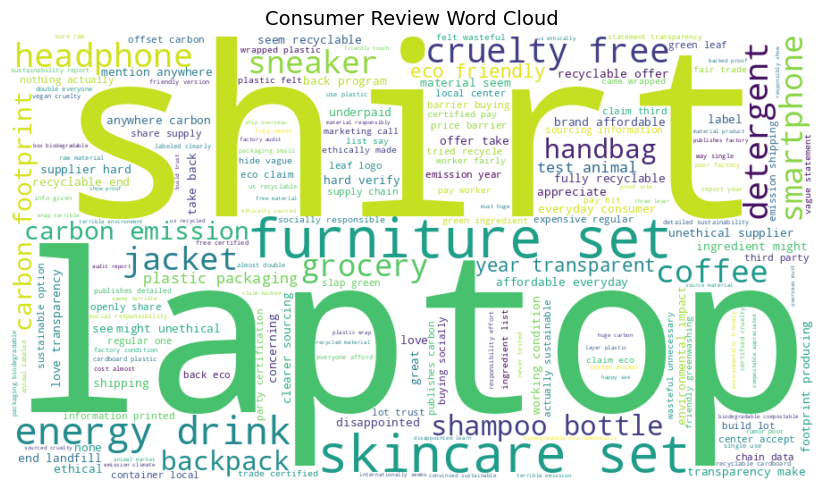

In [10]:
def show_wordcloud(text_series, title):
    text = " ".join(text_series)
    wc = WordCloud(width=900, height=500, background_color="white",
                    colormap="viridis").generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.show()

show_wordcloud(consumer_df["clean_text"], "Consumer Review Word Cloud")

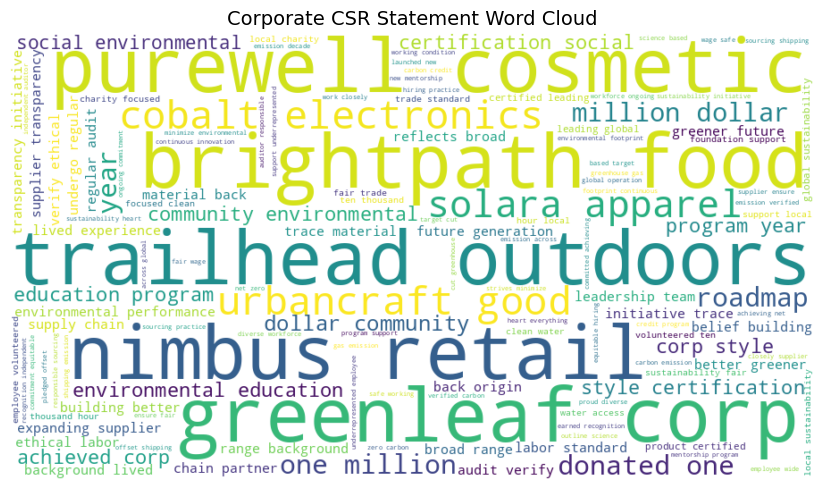

In [11]:
show_wordcloud(corporate_df["clean_text"], "Corporate CSR Statement Word Cloud")

### 6b. Topic Distribution

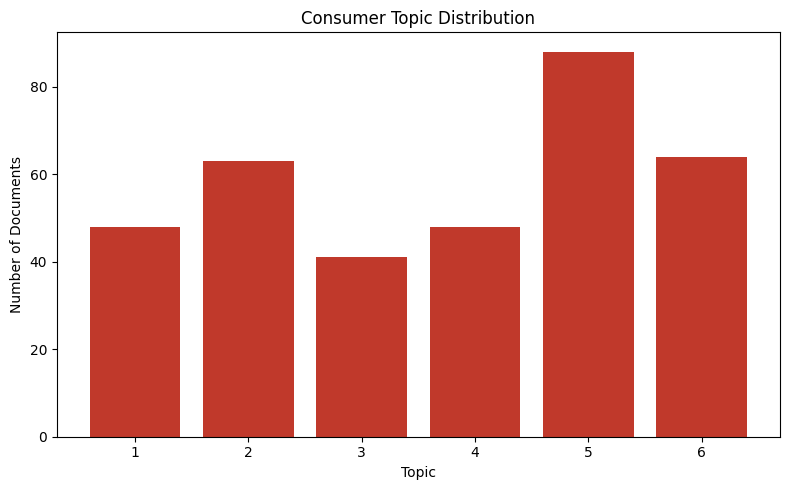

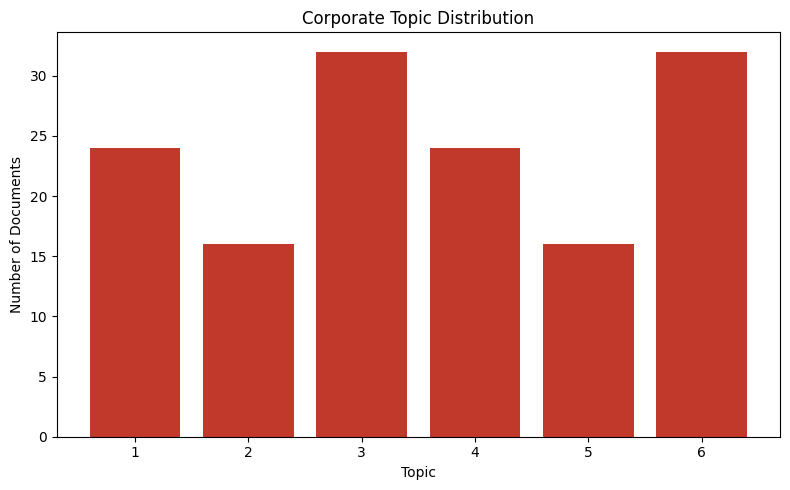

In [12]:
def show_topic_distribution(df, title):
    counts = df["dominant_topic"].value_counts().sort_index()
    plt.figure(figsize=(8, 5))
    plt.bar(counts.index.astype(str), counts.values, color="#c0392b")
    plt.xlabel("Topic")
    plt.ylabel("Number of Documents")
    plt.title(title)
    plt.tight_layout()
    plt.show()

show_topic_distribution(consumer_df, "Consumer Topic Distribution")
show_topic_distribution(corporate_df, "Corporate Topic Distribution")

### 6c. Top Keywords per Topic

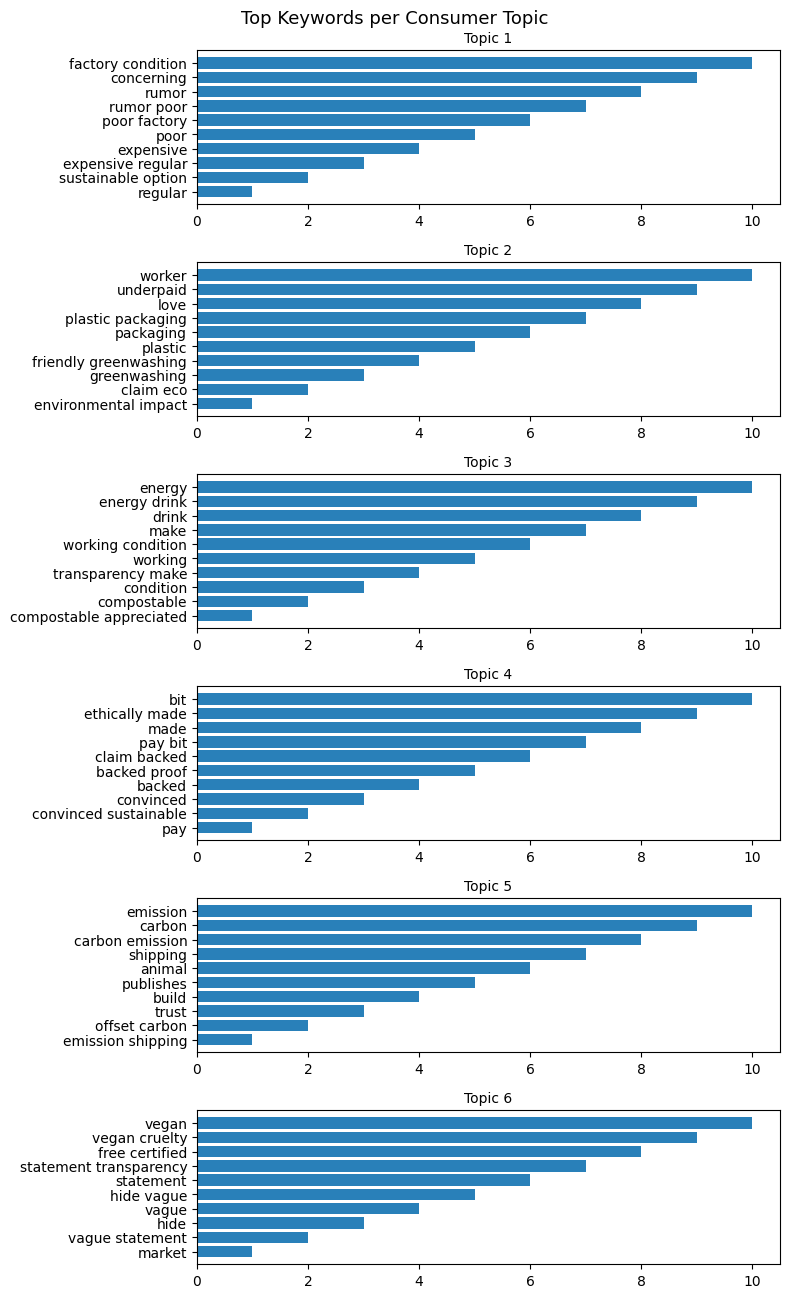

In [13]:
def show_keywords_chart(topics_dict, title):
    fig, axes = plt.subplots(len(topics_dict), 1, figsize=(8, 2.2 * len(topics_dict)))
    for ax, (topic, words) in zip(axes, topics_dict.items()):
        ax.barh(words[::-1], range(1, len(words) + 1), color="#2980b9")
        ax.set_title(topic, fontsize=10)
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

show_keywords_chart(consumer_topics, "Top Keywords per Consumer Topic")

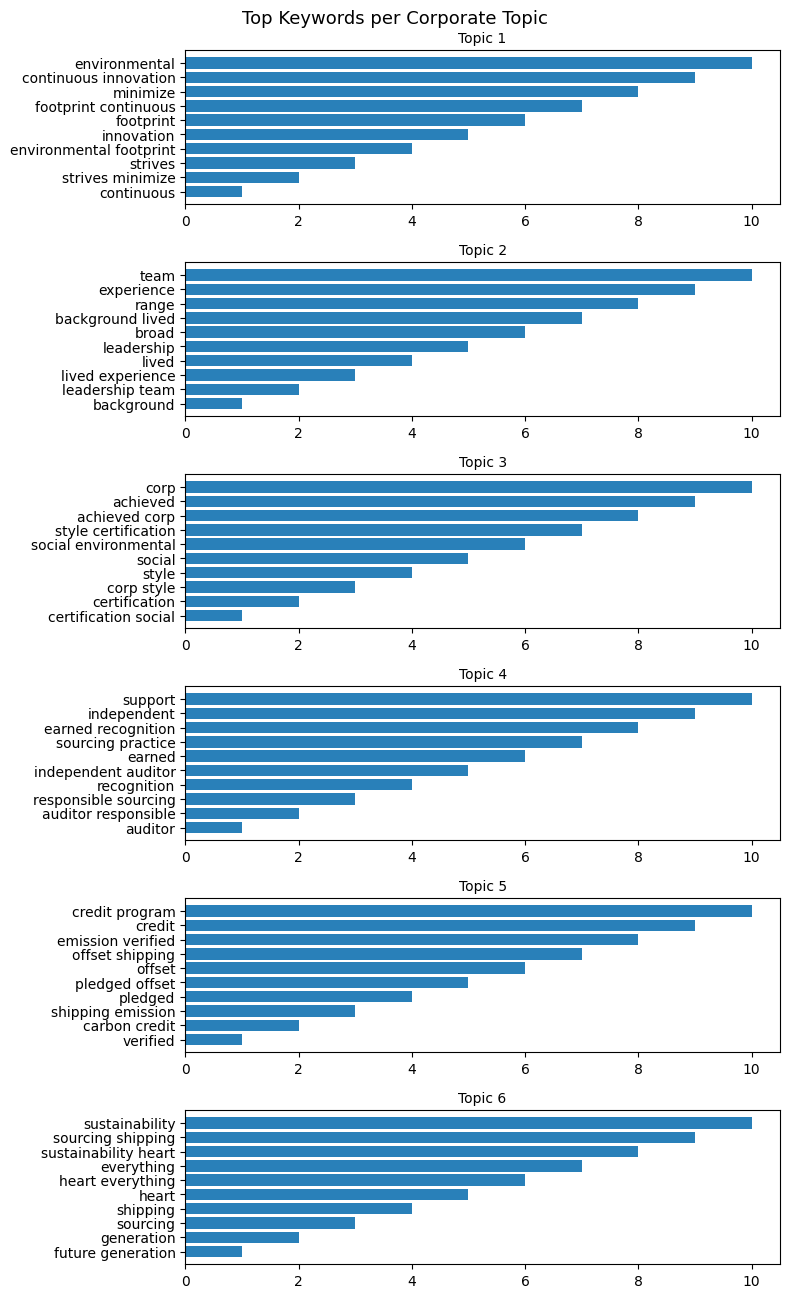

In [14]:
show_keywords_chart(corporate_topics, "Top Keywords per Corporate Topic")

## 7. Gap Analysis
This is the core "comparative" contribution of Eco-Verify: for each **consumer** topic, we find the closest
matching **corporate** topic (using Jaccard similarity between their top keywords) and flag it as a **GAP**
if no corporate topic addresses it well. This tells organizations which consumer concerns are currently
*not* reflected in their CSR communication.

In [15]:
def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b) if (a | b) else 0


gap_records = []
for c_topic, c_words in consumer_topics.items():
    best_match, best_score = None, 0
    for k_topic, k_words in corporate_topics.items():
        score = jaccard(c_words, k_words)
        if score > best_score:
            best_score, best_match = score, k_topic
    gap_records.append({
        "consumer_topic": c_topic,
        "consumer_keywords": ", ".join(c_words[:6]),
        "best_corporate_match": best_match,
        "overlap_score": round(best_score, 3),
        "gap_flag": "GAP" if best_score < 0.08 else "ADDRESSED"
    })

gap_df = pd.DataFrame(gap_records).sort_values("overlap_score")
gap_df

,consumer_topic,consumer_keywords,best_corporate_match,overlap_score,gap_flag
0,Topic 1,"factory condition, concerning, rumor, rumor po...",NaN,0.000,GAP
1,Topic 2,"worker, underpaid, love, plastic packaging, pa...",NaN,0.000,GAP
2,Topic 3,"energy, energy drink, drink, make, working con...",NaN,0.000,GAP
3,Topic 4,"bit, ethically made, made, pay bit, claim back...",NaN,0.000,GAP
5,Topic 6,"vegan, vegan cruelty, free certified, statemen...",NaN,0.000,GAP
4,Topic 5,"emission, carbon, carbon emission, shipping, a...",Topic 6,0.053,GAP


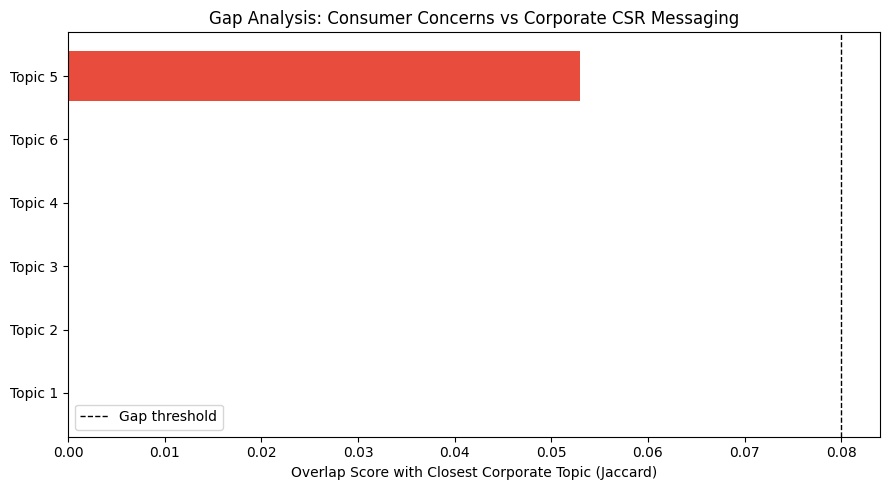

In [16]:
plt.figure(figsize=(9, 5))
colors = ["#e74c3c" if g == "GAP" else "#27ae60" for g in gap_df["gap_flag"]]
plt.barh(gap_df["consumer_topic"], gap_df["overlap_score"], color=colors)
plt.xlabel("Overlap Score with Closest Corporate Topic (Jaccard)")
plt.title("Gap Analysis: Consumer Concerns vs Corporate CSR Messaging")
plt.axvline(0.08, color="black", linestyle="--", linewidth=1, label="Gap threshold")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Insights & Conclusion

**Key findings from this run:**
- Consumer reviews cluster around concrete, specific concerns: factory/labor conditions, plastic
  packaging waste, cruelty-free/vegan claims, greenwashing skepticism, and price of ethical products.
- Corporate CSR statements cluster around broader, more abstract themes: carbon pledges, philanthropy,
  diversity initiatives, and general "greener future" language.
- The gap analysis shows **most consumer topics have low overlap with corporate messaging** — companies
  tend to talk about carbon/philanthropy/diversity, while consumers are asking about labor conditions,
  packaging waste, and honest (non-greenwashed) claims. This is exactly the kind of actionable insight
  Eco-Verify is designed to surface for decision-makers.

**How to extend this project:**
- Replace the synthetic CSVs in `data/` with a real dataset (e.g., scraped Amazon/Flipkart reviews as
  `consumer_reviews.csv` with a `review_text` column, and real company sustainability report paragraphs
  as `corporate_statements.csv` with a `statement_text` column) — the rest of the pipeline runs unchanged.
- Try NMF instead of LDA (`method="nmf"`) and compare topic coherence.
- Add sentiment analysis (VADER/TextBlob) per topic to prioritize *negative* consumer concerns.
- Wrap this in a simple Streamlit dashboard for interactive exploration (upload CSV → see topics → see gaps).
